# Data Generation and Loading Demo

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [10]:

from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.express as px
import sys
import tifffile as tf
from typing import Tuple, Optional

sys.path.append("..")
from data_prep import load, generate, draw
from neurotrack.data import neuron_data

# Data Synthesis

Load some real data

In [3]:
tifs_root = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset")
swc_root = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset")

tifs = sorted(list(tifs_root.glob("*.tif")))
swcs = sorted(list(swc_root.glob("*.swc")))
print(f"Found {len(tifs)} tifs and {len(swcs)} swcs")


Found 30 tifs and 30 swcs


Look at an image

Loading /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/080926a_image.tif


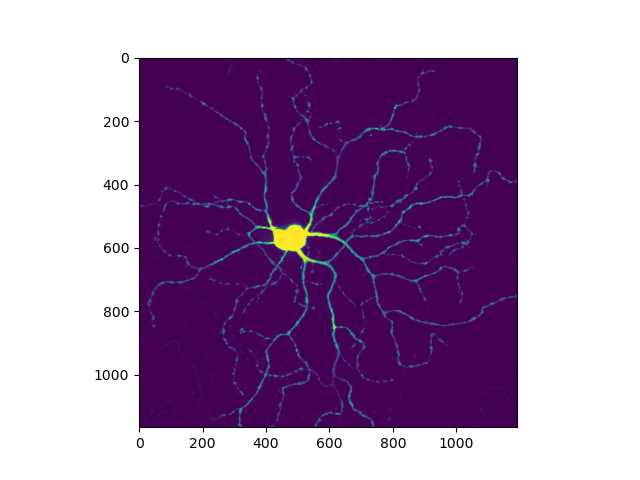

In [4]:
tif = tifs[0]
print(f"Loading {tif}")
img = tf.imread(tif)

fig = plt.figure()
plt.imshow(np.max(img, axis=0))  # max projection
plt.show()

Look at the morphology

In [5]:
def plot_sections(sections):
    # Create a DataFrame for plotting
    data = []
    # Iterate through the sections dictionary
    for section_id, section_data in sections.items():
        # flatten the section into one list of consecutive points instead of segments (point pairs)
        for i,segment in enumerate(section_data):
            point = segment[0] 
            data.append([section_id, point[0].item(), point[1].item(), point[2].item()])
            if i == len(section_data)-1:
                point = segment[1]
                data.append([section_id, point[0].item(), point[1].item(), point[2].item()])
    df_sections = pd.DataFrame(data, columns=["section", "x", "y", "z"])

    fig = px.line_3d(df_sections, x="x", y="y", z="z", color='section', )
    fig.update_layout(scene_aspectmode='data')
    fig.show()

In [6]:
swc = swcs[0]

swc_list = load.swc(swc)
sections, sections_graph = load.parse_swc(swc_list)

plot_sections(sections)

loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/080926a.swc


Goal is to synthesize data with a range of complexity in terms of morphology and contrast\
with the most complex data mimicking the real data as closely as possible.

## Morphology

Simplest: A straight line in a random direction

In [7]:
swc_list = generate.make_swc_list(
    size=(100, 100, 100),
    length=50,
    step_size=1.0,
    kappa=1000.0,
    num_branches=0,
    rng=None
)

sections, sections_graph = load.parse_swc(swc_list)

plot_sections(sections)

Increase complexity by extracting sections from the real tree\
Greater complexity = larger sections & more branches

In [8]:
swc = swcs[0]
swc_list = load.swc(swc)

complexity = 0.9
data_generator = neuron_data.DataGenerator()

# Determine subtree extraction mode
# possible modes: "no_branch", "one_branch", "any_branch"
subtree_mode = data_generator._complexity_to_mode(complexity)
print(f"Using subtree extraction mode: {subtree_mode}")
# Determine target path length based on complexity and mode
target_path_len = 50.0 + {"no_branch": 100.0,
                            "one_branch": 500.0,
                            "any_branch": 5000.0}[subtree_mode] * complexity
print(f"Using target path length: {target_path_len}")

subtrees = data_generator.get_subtrees(swc_list, target_path_len, num_subtrees=1, mode=subtree_mode)
subtree = subtrees[0]
sections, sections_graph = load.parse_swc(subtree)
plot_sections(sections)

loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/080926a.swc
Using subtree extraction mode: any_branch
Using target path length: 4550.0


## Image Contrast

For image contrast, the simplest contrast is a curve with a constant width, ones in foreground
zeros in background, and added blur.

In [9]:
coords = np.array(subtree)[:, 2:5]                
shape_estimate = tuple(int(x) + 20 for x in np.ptp(coords, axis=0))[::-1] # Reverse for z,y,x

# shift coords
subtree_ = np.array(subtree)
subtree_[:, 2:5] = subtree_[:, 2:5] - coords.min(axis=0) + 10.0
subtree = subtree_.tolist()
sections, sections_graph = load.parse_swc(subtree_)

# Initialize the NeuronRenderer with a fixed random seed for reproducibility
renderer = draw.NeuronRenderer(rng=np.random.default_rng(0))

In [23]:
@dataclass
class DrawingConfig:
    """Configuration for neuron drawing parameters."""
    width: float = 4.0
    
    foreground_mean: float = 0.8
    foreground_std: float = 0.1
    background_mean: float = 0.2
    background_std: float = 0.05
    mask_threshold: float = 0.1  # Fraction of max value for foreground/background mask
    spatial_noise_scale: float = 10.0  # Scale for spatial noise features
    spatial_noise_amplitude: float = 1.0  # Amplitude multiplier for spatial noise contribution
    noise_method: str = 'gaussian_convolution'  # Method for spatial noise: 'gaussian_convolution', 'fractal', 'sparse_kernel'
    blur: float = 1.0  # Sigma for optional Gaussian smoothing applied during post-processing
    sharpness: float = 1.0  # Sharpness parameter for line drawing edges
    vignette_magnitude: float = 0.2  # Strength of vignette effect (0 disables)
    width_correlation: bool = False
    width_correlation_rho: float = 0.0  # target lag-1 correlation for widths when enabled
    segment_intensity_correlation: bool = False
    segment_intensity_correlation_rho: float = 0.0  # target lag-1 correlation for per-segment intensity when enabled
    
    def __post_init__(self):
        """Validate configuration parameters."""
        if not 0 <= self.mask_threshold <= 1:
            raise ValueError("mask_threshold must be between 0 and 1")
        if self.spatial_noise_amplitude < 0:
            raise ValueError("spatial_noise_amplitude must be non-negative")
        if self.noise_method not in ['gaussian_convolution', 'fractal', 'sparse_kernel']:
            raise ValueError("noise_method must be one of: 'gaussian_convolution', 'fractal', 'sparse_kernel'")
        # Validate correlations
        if self.width_correlation and not (-1.0 <= float(self.width_correlation_rho) <= 1.0):
            raise ValueError("width_correlation_rho must be in (-1.0, 1.0) when width_correlation=True")
        if self.segment_intensity_correlation and not (-1.0 <= float(self.segment_intensity_correlation_rho) <= 1.0):
            raise ValueError("segment_intensity_correlation_rho must be in (-1.0, 1.0) when segment_intensity_correlation=True")

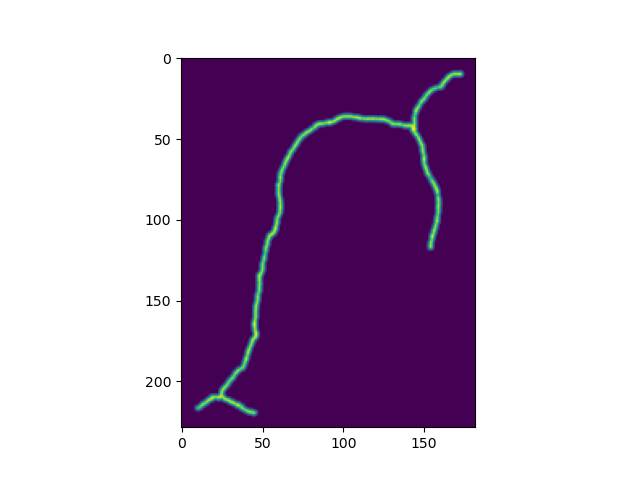

In [11]:
config = draw.DrawingConfig(
    width=3,
    foreground_mean=1.0,
    foreground_std=0.0,
    background_mean=0.0,
    background_std=0.0,
    spatial_noise_amplitude=0.0,
    vignette_magnitude=0.0,
    width_correlation=False,
    width_correlation_rho=0.0,
    segment_intensity_correlation=False,
    segment_intensity_correlation_rho=0.0,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

Add complexity by adjusting several factors:
- variable path width
- variable edge intensity value
- Foreground mean
- Foreground standard deviation
- Background mean
- Background standard deviation
- Spatially correlated noise
- Vignette

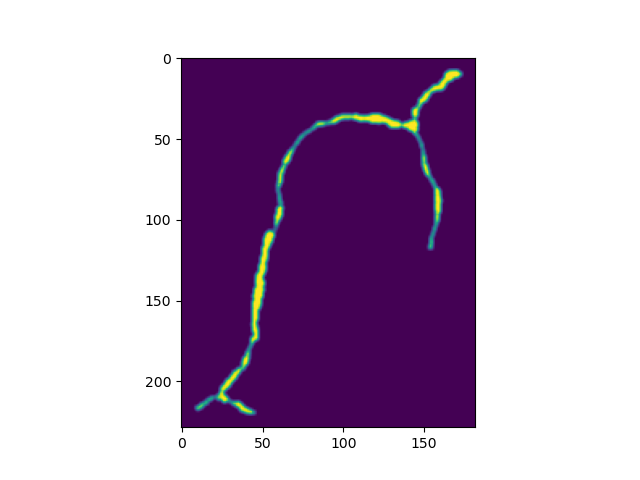

In [12]:
# Variable path width
config = draw.DrawingConfig(
    width=3,
    foreground_mean=1.0,
    foreground_std=0.0,
    background_mean=0.0,
    background_std=0.0,
    spatial_noise_amplitude=0.0,
    vignette_magnitude=0.0,
    width_correlation=True,
    width_correlation_rho=0.7,
    segment_intensity_correlation=False,
    segment_intensity_correlation_rho=0.0,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
plt.close('all')
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

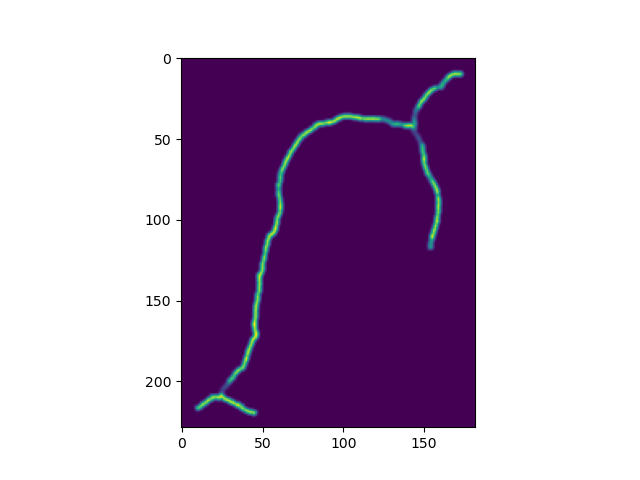

In [13]:
# Variable edge intensity
config = draw.DrawingConfig(
    width=3,
    foreground_mean=1.0,
    foreground_std=0.0,
    background_mean=0.0,
    background_std=0.0,
    spatial_noise_amplitude=0.0,
    vignette_magnitude=0.0,
    width_correlation=False,
    width_correlation_rho=0.0,
    segment_intensity_correlation=True,
    segment_intensity_correlation_rho=0.9,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

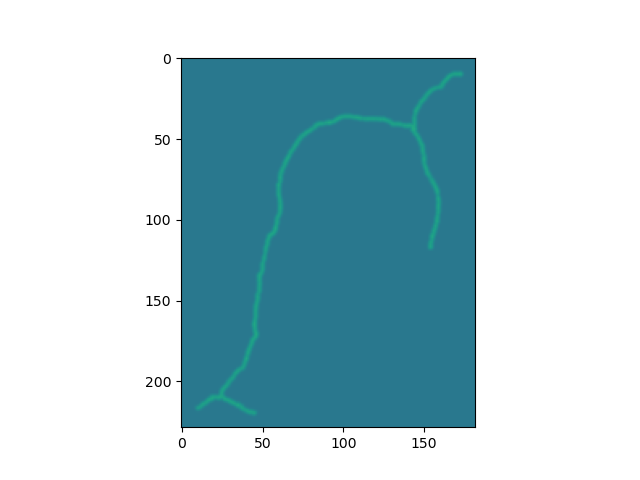

In [14]:
# Lower FG/BG contrast
config = draw.DrawingConfig(
    width=3,
    foreground_mean=0.6,
    foreground_std=0.0,
    background_mean=0.4,
    background_std=0.0,
    spatial_noise_amplitude=0.0,
    vignette_magnitude=0.0,
    width_correlation=False,
    width_correlation_rho=0.0,
    segment_intensity_correlation=False,
    segment_intensity_correlation_rho=0.0,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

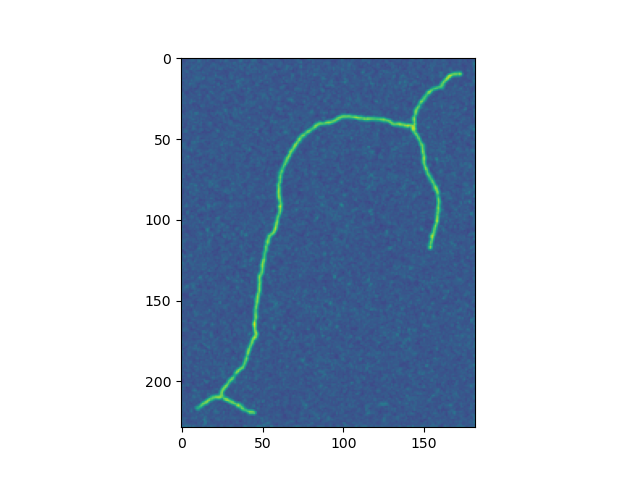

In [15]:
# Increase foreground/background noise
config = draw.DrawingConfig(
    width=3,
    foreground_mean=1.0,
    foreground_std=0.3,
    background_mean=0.1,
    background_std=0.3,
    spatial_noise_amplitude=0.0,
    vignette_magnitude=0.0,
    width_correlation=False,
    width_correlation_rho=0.0,
    segment_intensity_correlation=False,
    segment_intensity_correlation_rho=0.0,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

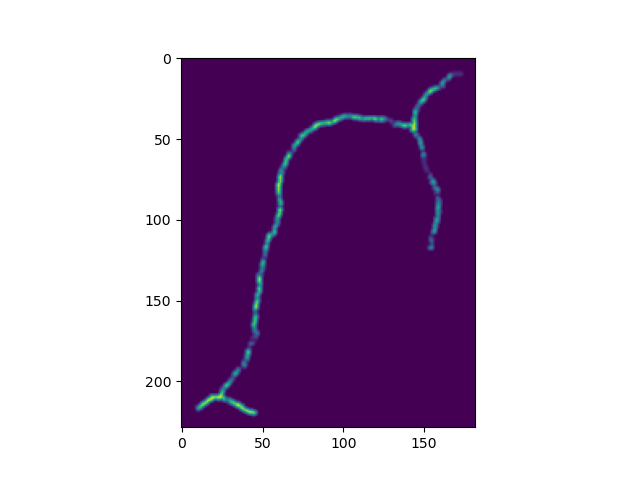

In [16]:
# Add spatially correlated noise
config = draw.DrawingConfig(
    width=3,
    foreground_mean=1.0,
    foreground_std=0.0,
    background_mean=0.0,
    background_std=0.0,
    spatial_noise_scale=2.0,
    spatial_noise_amplitude=2.0,
    vignette_magnitude=0.0,
    width_correlation=False,
    width_correlation_rho=0.7,
    segment_intensity_correlation=True,
    segment_intensity_correlation_rho=0.9,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

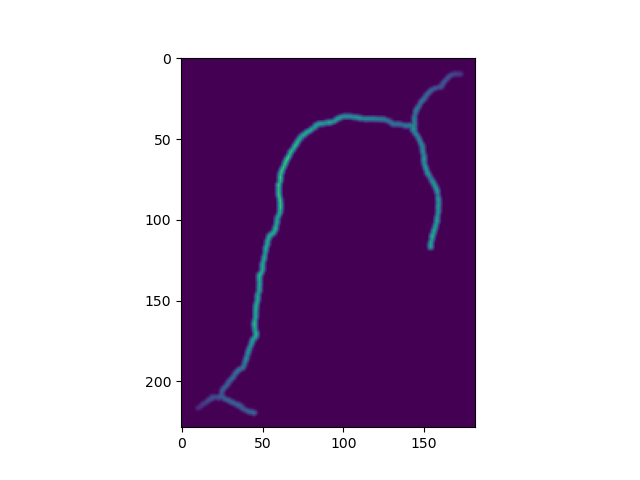

In [17]:
# Add vignette
config = draw.DrawingConfig(
    width=3,
    foreground_mean=1.0,
    foreground_std=0.0,
    background_mean=0.0,
    background_std=0.0,
    spatial_noise_amplitude=0.0,
    vignette_magnitude=2.0,
    width_correlation=False,
    width_correlation_rho=0.0,
    segment_intensity_correlation=False,
    segment_intensity_correlation_rho=0.0,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

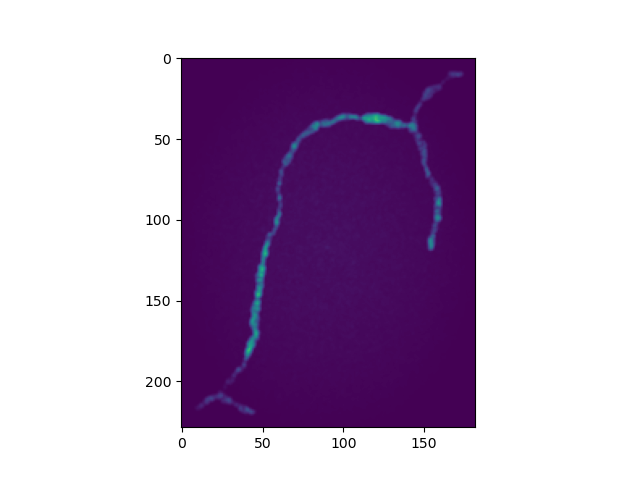

In [26]:
# Put them all together
config = DrawingConfig(
    width=3,
    foreground_mean=0.6,
    foreground_std=0.35,
    background_mean=0.02,
    background_std=0.04,
    spatial_noise_scale=3.0,
    spatial_noise_amplitude=1.0,
    vignette_magnitude=2.0,
    width_correlation=True,
    width_correlation_rho=0.7,
    segment_intensity_correlation=True,
    segment_intensity_correlation_rho=0.9,
    blur=1.0
)

img = renderer.draw_neuron(sections, shape_estimate, config)
fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()

## Given complexity, $c \in [0.0, 1.0]$, generate data

Specify a range for each factor

In [20]:
@dataclass
class DrawingComplexityConfig:
    """Configuration for complexity-based drawing parameters."""

    width_correlation_rho_range: Tuple[float, float] = (0.7, 1.0)
    segment_intensity_correlation_rho_range: Tuple[float, float] = (0.9, 1.0)
    # Foreground parameters
    foreground_mean_range: Tuple[float, float] = (0.6, 1.0)
    foreground_std_range: Tuple[float, float] = (0.0, 0.35)
    # Background parameters
    background_mean_range: Tuple[float, float] = (0.0, 0.02)
    background_std_range: Tuple[float, float] = (0.0, 0.04)
    # Spatial noise parameters
    spatial_noise_amplitude_range: Tuple[float, float] = (0.0, 1.0)

    # Vignette magnitude [min, max]
    vignette_magnitude_range: Tuple[float, float] = (0.0, 2.0)
    
    def interpolate_config(self, complexity: float) -> 'draw.DrawingConfig':
        """
        Interpolate drawing configuration based on complexity (0.0 to 1.0).
        Higher complexity = more artifacts and variation.
        """
        complexity = max(0.0, min(1.0, complexity))
        
        def lerp(min_val, max_val, t):
            return min_val + t * (max_val - min_val)
        
        return DrawingConfig(
            # Fixed parameters
            width=3.0,
            blur=1.0,
            sharpness=2.0,
            mask_threshold=0.1,
            spatial_noise_scale=3.0,
            width_correlation=True,
            # Interpolated parameters
            width_correlation_rho=lerp(*self.width_correlation_rho_range, 1.0 - complexity),
            segment_intensity_correlation=True,
            segment_intensity_correlation_rho=lerp(*self.segment_intensity_correlation_rho_range, 1.0 - complexity),
            foreground_mean=lerp(*self.foreground_mean_range, 1.0 - complexity),  # Less mean for higher complexity
            foreground_std=lerp(*self.foreground_std_range, complexity),
            background_mean=lerp(*self.background_mean_range, complexity),  # More background for complexity
            background_std=lerp(*self.background_std_range, complexity),
            spatial_noise_amplitude=lerp(*self.spatial_noise_amplitude_range, complexity),
            vignette_magnitude=lerp(*self.vignette_magnitude_range, complexity)
        )

DataGenerator class takes DrawingComplexityConfig as input at instantiation.
When generating a new image, a scalar complexity is converted to a vector of complexity parameters.

In [21]:
complexity_config = DrawingComplexityConfig()
data_generator = neuron_data.DataGenerator(cache_dir="../data_cache", complexity_config=complexity_config)

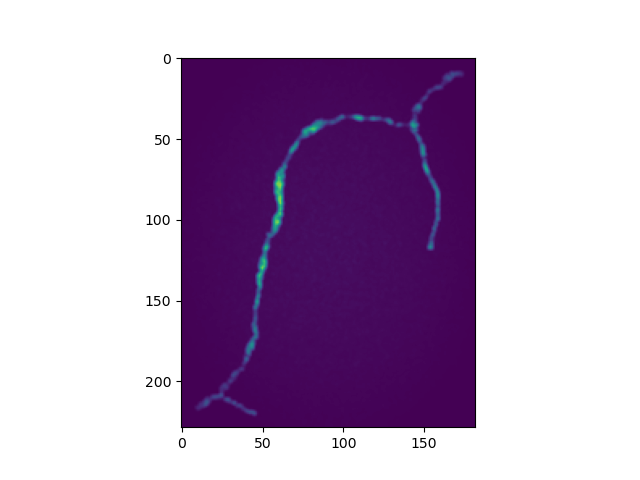

In [31]:
# Simulate a single neuron image with specified complexity
complexity = 0.9
config = complexity_config.interpolate_config(complexity)
img = data_generator.simulate_neuron_image(subtree, shape_estimate, config)

fig = plt.figure()
plt.imshow(img.data[0].amax(0), vmin=0, vmax=1)
plt.show()


Generate a batch of synthetic data

In [35]:
swc_root = "/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset"
data_generator.generate_data(swc_dir=swc_root, subtrees_per_swc=1, complexity_range=(0.0, 1.0))

Processing 30 SWC files...
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/3_CL-I_MT_X_MYR-GFP_ddaE_MT-mCherry_membrane-GFP.swc
Processed 3_CL-I_MT_X_MYR-GFP_ddaE_MT-mCherry_membrane-GFP: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140921c5.swc
Processed 140921c5: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091201c1.swc
Processed 091201c1: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-I_X_OREGON_R_ddaE_membrane-GFP.swc
Processed 1_CL-I_X_OREGON_R_ddaE_membrane-GFP: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091204c2.swc
Processed 091204c2: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140921c4.swc
Processed 140921c4: 1 

{'processed_files': 30, 'total_subtrees': 30, 'output_dir': '../data_cache'}

In [81]:
# You can also use the data generator to chop up the original images into smaller sections for training
data_generator.empty_cache()
img_dir = "/home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset"
data_generator.generate_data(swc_dir=swc_root, img_dir=img_dir, subtrees_per_swc=1, complexity_range=(0.0, 1.0))

Cache directory ../data_cache emptied.
Processing 30 SWC files...
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/3_CL-I_MT_X_MYR-GFP_ddaE_MT-mCherry_membrane-GFP.swc
Processed 3_CL-I_MT_X_MYR-GFP_ddaE_MT-mCherry_membrane-GFP: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140921c5.swc
Processed 140921c5: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091201c1.swc


/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [ 6.16698988  0.6065     95.326     ] is out of bounds for image shape torch.Size([6, 161, 95]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [ 6.89510961 14.177      89.182     ] is out of bounds for image shape torch.Size([6, 161, 95]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [  3.30130691 161.           0.628     ] is out of bounds for image shape torch.Size([6, 161, 95]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [  3.44182125 161.           1.9615    ] is out of bounds for image shape torch.Size([6, 161, 95]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [  3.4418212

Processed 091201c1: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-I_X_OREGON_R_ddaE_membrane-GFP.swc
Processed 1_CL-I_X_OREGON_R_ddaE_membrane-GFP: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091204c2.swc


/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [25.2732  2.035   6.605 ] is out of bounds for image shape torch.Size([25, 23, 63]). Translating to the nearest valid index.



Processed 091204c2: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140921c4.swc


...

Processed 100108c3: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/110203c3.swc


/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [ 0.78148 44.0632   0.60964] is out of bounds for image shape torch.Size([18, 44, 23]). Translating to the nearest valid index.



Processed 110203c3: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby.swc
Processed 1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby: 1 subtrees generated
Entry data saved to: ../data_cache/generated_data_entries.csv

Processing complete!
Total subtrees generated: 30
Results saved to: ../data_cache


/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [  2.33333333 210.362       49.71      ] is out of bounds for image shape torch.Size([8, 210, 55]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [  0.85185 112.584    55.6    ] is out of bounds for image shape torch.Size([8, 210, 55]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [  2.33333333 106.473       55.6       ] is out of bounds for image shape torch.Size([8, 210, 55]). Translating to the nearest valid index.

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:261: UserWarning:

Center [ 8.62966667 41.806      26.27      ] is out of bounds for image shape torch.Size([8, 210, 55]). Translating to the nearest valid index.



{'processed_files': 30, 'total_subtrees': 30, 'output_dir': '../data_cache'}

In [94]:
# Or generate data from scratch without any input SWCs or images
data_generator.empty_cache()
data_generator.generate_data(dataset_size=30, complexity_range=(0.0, 1.0))

Cache directory ../data_cache emptied.
Processing 30 synthetic neurons...
Processed simulated_img0: 1 subtrees generated
Processed simulated_img1: 1 subtrees generated
Processed simulated_img2: 1 subtrees generated
Processed simulated_img3: 1 subtrees generated
Processed simulated_img4: 1 subtrees generated
Processed simulated_img5: 1 subtrees generated
Processed simulated_img6: 1 subtrees generated
Processed simulated_img7: 1 subtrees generated
Processed simulated_img8: 1 subtrees generated
Processed simulated_img9: 1 subtrees generated
Processed simulated_img10: 1 subtrees generated
Processed simulated_img11: 1 subtrees generated
Processed simulated_img12: 1 subtrees generated
Processed simulated_img13: 1 subtrees generated
Processed simulated_img14: 1 subtrees generated
Processed simulated_img15: 1 subtrees generated
Processed simulated_img16: 1 subtrees generated
Processed simulated_img17: 1 subtrees generated
Processed simulated_img18: 1 subtrees generated
Processed simulated_img1

{'processed_files': 30, 'total_subtrees': 30, 'output_dir': '../data_cache'}

Data generator writes a CSV file to save complexity values of generated data.

In [95]:
entries = pd.read_csv(data_generator.cache_dir / "generated_data_entries.csv")
entries

,neuron_name,complexity,morphology
0,simulated_img0_subtree_00,0.459293,moderate
1,simulated_img1_subtree_00,0.728718,complex
2,simulated_img2_subtree_00,0.577886,moderate
3,simulated_img3_subtree_00,0.125195,simple
4,simulated_img4_subtree_00,0.881911,complex
5,simulated_img5_subtree_00,0.939202,full
6,simulated_img6_subtree_00,0.793544,complex
7,simulated_img7_subtree_00,0.408677,moderate
8,simulated_img8_subtree_00,0.066658,simple
9,simulated_img9_subtree_00,0.149516,simple


# Data Loading

Dataset class stores data paths and complexities

In [96]:
dataset = neuron_data.Dataset(data_generator.cache_dir)
for e in dataset.entries:
    print(e['neuron_name'])
dataset.get_complexity_distribution()


simulated_img0_subtree_00
simulated_img1_subtree_00
simulated_img2_subtree_00
simulated_img3_subtree_00
simulated_img4_subtree_00
simulated_img5_subtree_00
simulated_img6_subtree_00
simulated_img7_subtree_00
simulated_img8_subtree_00
simulated_img9_subtree_00
simulated_img10_subtree_00
simulated_img11_subtree_00
simulated_img12_subtree_00
simulated_img13_subtree_00
simulated_img14_subtree_00
simulated_img15_subtree_00
simulated_img16_subtree_00
simulated_img17_subtree_00
simulated_img18_subtree_00
simulated_img19_subtree_00
simulated_img20_subtree_00
simulated_img21_subtree_00
simulated_img22_subtree_00
simulated_img23_subtree_00
simulated_img24_subtree_00
simulated_img25_subtree_00
simulated_img26_subtree_00
simulated_img27_subtree_00
simulated_img28_subtree_00
simulated_img29_subtree_00


{'morphology_distribution': {'moderate': 12,
  'complex': 8,
  'simple': 7,
  'full': 3},
 'complexity_stats': {'mean': 0.5678134736538217,
  'std': 0.2671941910509159,
  'min': 0.0666583169193615,
  'max': 0.991396743342269}}

DataLoader class performs weighted data sampling using the given target complexity to weight data entries.

In [ ]:
# DataLoader methods

def _update_sampling_weights(self):
    """Update sampling weights based on current complexity parameter."""
    if len(self.dataset) == 0:
        self.weights = []
        return
        
    weights = []
    for entry in self.dataset.entries:
        # Combine artifact level and morphology complexity
        complexity = entry['complexity']
        
        # Weight based on how close the neuron complexity is to target complexity
        weight = np.exp(-8*abs(complexity - self.complexity)) # exponential decay

        # Ensure positive weights
        weight = max(1e-4, weight)
        weights.append(weight)
    
    # Normalize weights
    total_weight = sum(weights)
    self.weights = [w / total_weight for w in weights] if total_weight > 0 else weights


def sample(self) -> Dict:
    """Sample a neuron based on current complexity weights."""
    if len(self.dataset) == 0:
        raise ValueError("Dataset is empty")
    
    if not self.weights:
        # Fallback to uniform sampling
        idx = self.rng.integers(0, len(self.dataset))
    else:
        idx = self.rng.choice(len(self.dataset), p=self.weights)
    self.current_idx = idx
    
    return self.dataset[idx]

In [97]:
dataloader = neuron_data.DataLoader(dataset, complexity=0.0)

Sampled image path: ../data_cache/simulated_img9_subtree_00_image.tif
Sampled complexity: 0.1495164864569415


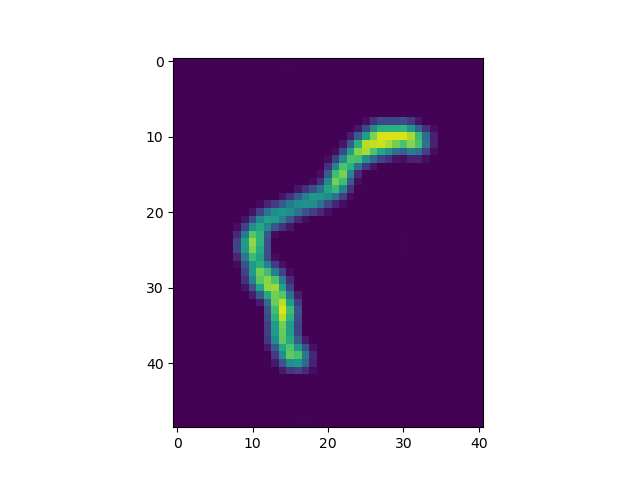

In [107]:
dataloader.set_complexity(0.0)

entry = dataloader.sample()
img_path = entry['img_path']
print(f"Sampled image path: {img_path}")
print(f"Sampled complexity: {entry['complexity']}")
img = tf.imread(img_path)

if img.dtype != np.float32:
    img = img.astype(np.float32) / img.max()

plt.close('all')
fig = plt.figure()
plt.imshow(img[0].max(axis=0), vmin=0, vmax=1)
plt.show()

# Commmand line usage

In [ ]:
# clear the data cache first
data_generator.clear_cache()

!../bin/setup_sac_train_v1.py --swc_dir /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset --output_dir ../data_cache --complexity_range 0.0 1.0 --subtrees_per_swc 1 --remove_soma --rng_seed 1